In [91]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from generalized_contrastive_PCA import gcPCA
from sklearn.model_selection import KFold
import statsmodels.api as sm
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

In [3]:
data_dir = 'C:/user-link/Documents/data/preprocessed_data/'
out_path = 'C:/user-link/Documents/data/derivatives/'
scores_path = 'C:/user-link/Documents/data/LOR_scores'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


In [4]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [7]:
burst_times = all_bursts['waveform_times'] * 1000 

In [5]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

In [6]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [92]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

 bins: [-1.82512862e-04 -1.28555098e-05  1.37907743e-06  1.55336336e-05
  1.54923842e-04]
  subject: s02, gcPC0, q=0, n_bursts=521
 bins: [-1.86400957e-04 -2.26809325e-05 -6.05057803e-06  7.30388716e-06
  8.33571237e-05]
  subject: s02, gcPC1, q=0, n_bursts=521
 bins: [-1.28414596e-04 -2.81931907e-05  1.04332263e-06  3.55132383e-05
  1.26570948e-04]
  subject: s02, gcPC-2, q=0, n_bursts=521
 bins: [-1.19939260e-04 -2.66808649e-05  1.54161728e-06  2.65619356e-05
  1.01490731e-04]
  subject: s02, gcPC-1, q=0, n_bursts=521
 bins: [-1.82512862e-04 -1.28555098e-05  1.37907743e-06  1.55336336e-05
  1.54923842e-04]
  subject: s02, gcPC0, q=1, n_bursts=521
 bins: [-1.86400957e-04 -2.26809325e-05 -6.05057803e-06  7.30388716e-06
  8.33571237e-05]
  subject: s02, gcPC1, q=1, n_bursts=521
 bins: [-1.28414596e-04 -2.81931907e-05  1.04332263e-06  3.55132383e-05
  1.26570948e-04]
  subject: s02, gcPC-2, q=1, n_bursts=521
 bins: [-1.19939260e-04 -2.66808649e-05  1.54161728e-06  2.65619356e-05
  1.0149

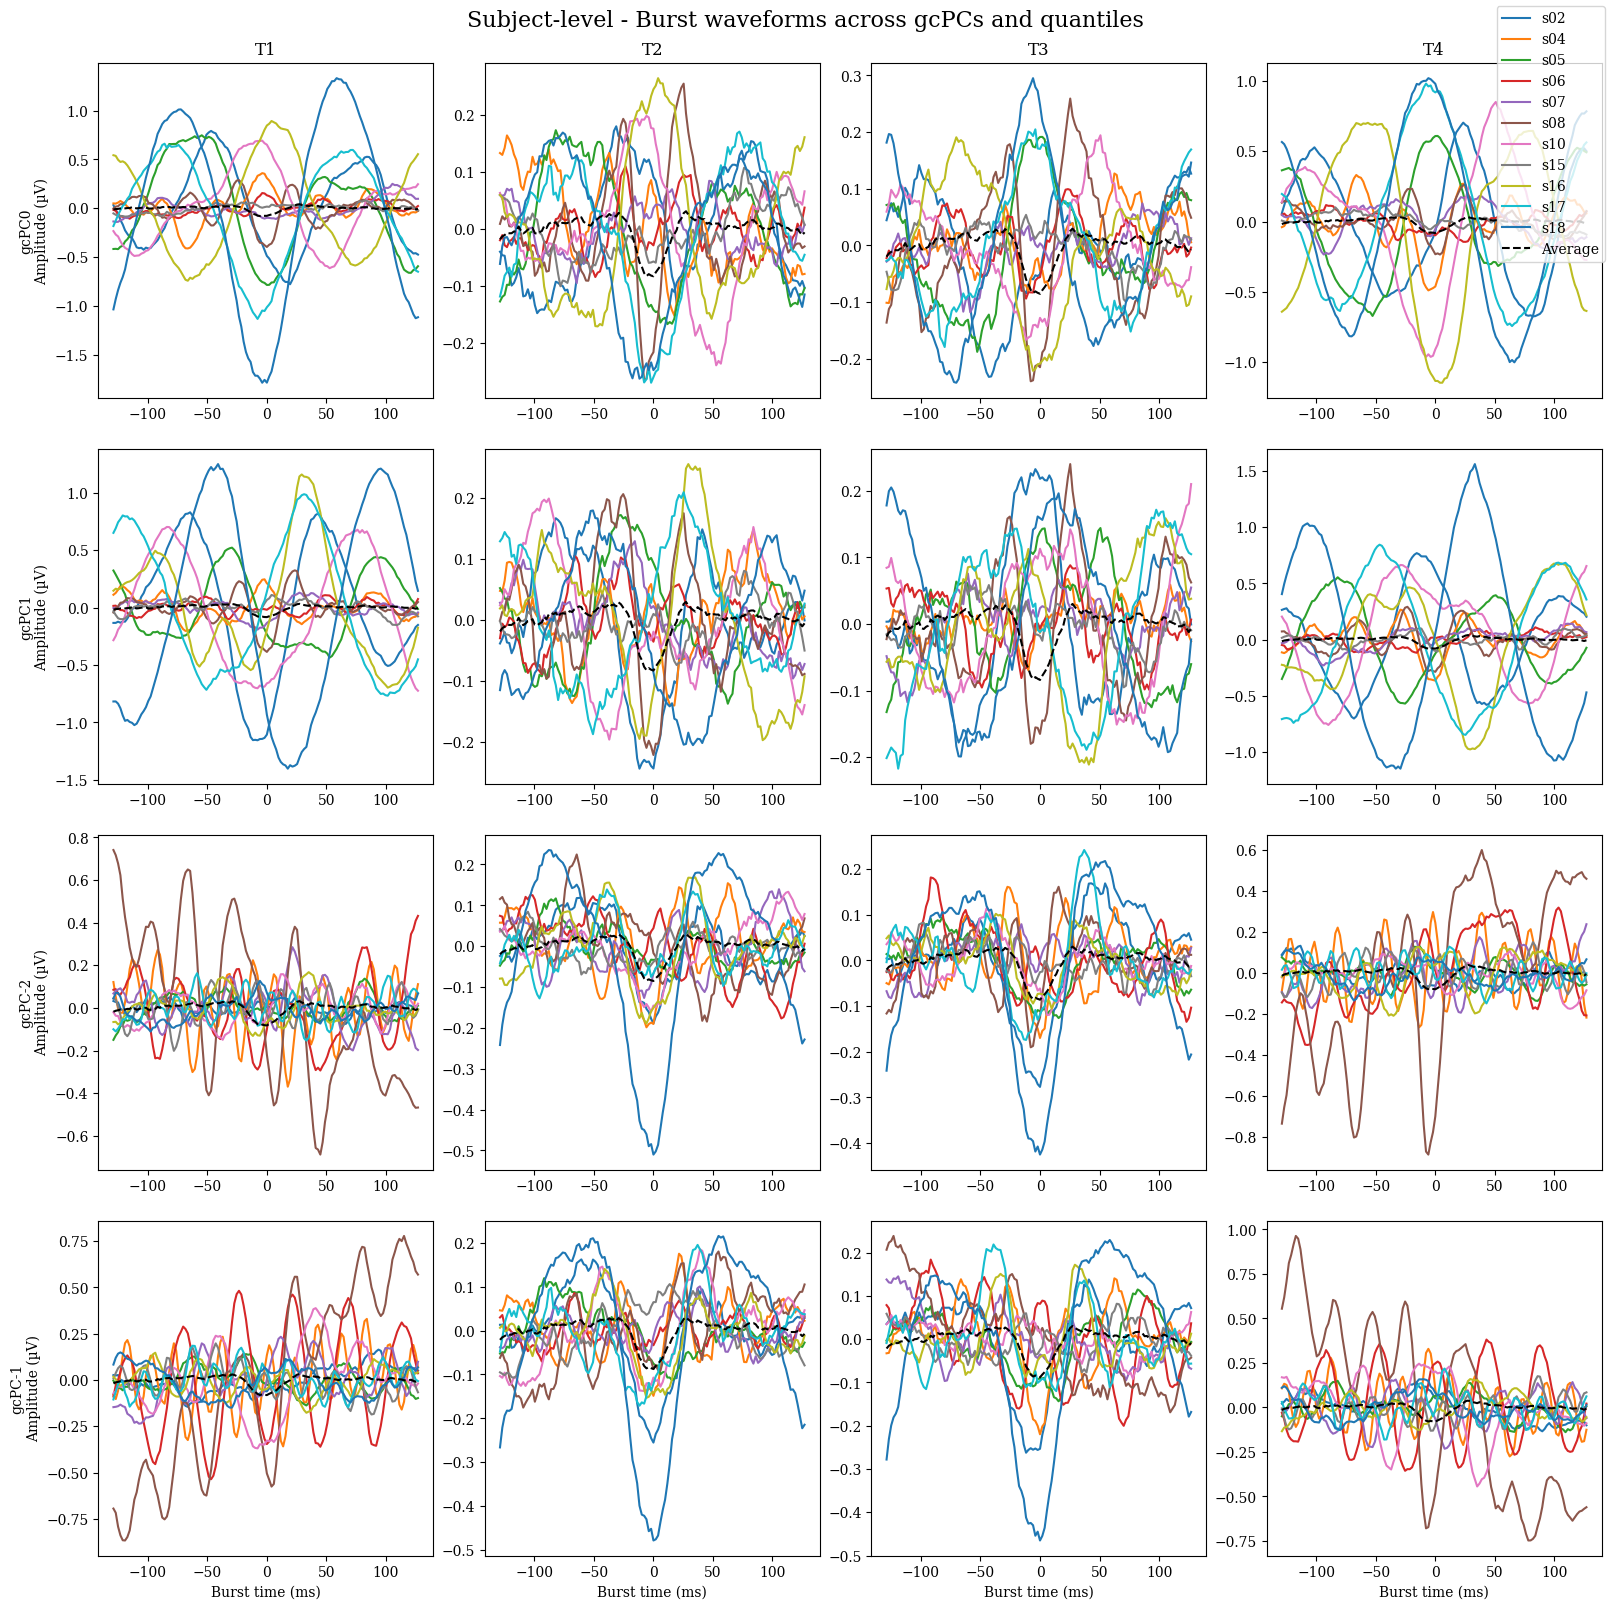

In [138]:
where = stn_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

n_q = 4
col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))
rev_col_r = col_r[::-1]
step = 100 / n_q

gcPC = [0, 1, -2, -1]

# fig, ax = plt.subplots(1, n_q, figsize=(3*n_q, len(gcPC)), constrained_layout=True)
fig, ax = plt.subplots(len(gcPC), n_q, figsize=(4*n_q, len(gcPC)*4), constrained_layout=True)


# subjects = np.array(subjects)
# n_splits = len(subjects)
# kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

# fold_scores = []
# train_fold_scores = []

# for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
#     train_subjects = subjects[train_s_idx]
#     test_subjects = subjects[test_s_idx]

#     # select bursts from training subjects (cortex channels only)
#     train_bursts_idx = np.isin(all_bursts['subject'], train_subjects) & where
#     train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
#     train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')

labels = []
q_waveforms = []
subjects_scores = []
for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    # scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the mean and std values
    median, mad = scaler_fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    subj_med = all_bursts['med'][subj_idx & where]
    subj_bursts = all_bursts['waveform'][subj_idx & where,:]
    subj_on_idx = (subj_med=='ON')
    subj_off_idx = (subj_med=='OFF')
    # subj_scaled_waveforms = scaler.transform(subj_bursts)
    subj_scaled_waveforms = scaler_transform(subj_bursts, median, mad)

    sub_gcpca_model = gcPCA(method='v4', normalize_flag=False)
    # sub_gcpca_model.fit(subj_bursts[subj_on_idx[train_s_idx],:], subj_bursts[subj_off_idx[train_s_idx],:])
    # sub_gcpca_model.fit(subj_scaled_waveforms[train_bursts_on_idx,:], subj_scaled_waveforms[train_bursts_off_idx,:])
    sub_gcpca_model.fit(subj_scaled_waveforms[subj_on_idx,:], subj_scaled_waveforms[subj_off_idx,:])
    subj_scores = subj_scaled_waveforms @ sub_gcpca_model.loadings_
    subjects_scores.append(subj_scores)

    # y_train_pred = sub_gcpca_model.predict(subj_bursts[train_bursts_idx,:])
    # train_score = 1 - np.sqrt(np.mean((subj_bursts[train_bursts_idx,:] - y_train_pred) ** 2))
    # y_train_pred = sub_gcpca_model.predict(subj_scaled_waveforms[train_bursts_idx,:])
    # train_score = 1 - np.sqrt(np.mean((subj_scaled_waveforms[train_bursts_idx,:] - y_train_pred) ** 2))

    # y_pred = sub_gcpca_model.predict(subj_bursts[test_subjects,:])
    # test_score = 1 - np.sqrt(np.mean((subj_bursts[test_subjects,:] - y_pred) ** 2))
    # y_pred = sub_gcpca_model.predict(subj_scaled_waveforms[test_subjects,:])
    # test_score = 1 - np.sqrt(np.mean((subj_scaled_waveforms[test_subjects,:] - y_pred) ** 2))

    # q_bins = np.percentile(subj_scores[:, 0], np.arange(0, 100+step, step))
    # q_bins = np.arange(np.min(subj_scores), np.max(subj_scores), (np.max(subj_scores)-np.min(subj_scores))/(n_q))
    # print(f'{subject}: score: min={np.min(subj_scores)}, max={np.max(subj_scores)}, train={train_score}, test={test_score}')

    # print(q_bins)
    for q in range(n_q):
        for col in gcPC:
            q_bins = np.percentile(subj_scores[:, col], np.arange(0, 100+step, step))
            print(" bins:", q_bins)

            if q==(n_q-1):
                lims = (subj_scores[:, col] >= q_bins[q])
            else:
                lims = (subj_scores[:, col] >= q_bins[q]) & (subj_scores[:, col] < q_bins[q+1])
            print(f'  subject: {subject}, gcPC{col}, q={q}, n_bursts={len(np.where(lims)[0])}')
            q_waveform = np.mean(subj_scaled_waveforms[lims, :], axis=0)
            q_waveforms.append(q_waveform)

            if len(np.where(lims)[0]) > 0:
                label = f'{subject}'
            else:
                label = None

            if label not in labels:
                labels.append(label)

            ax[col, q].plot(burst_times, q_waveform, label=label)
            ax[len(gcPC)-1, q].set_xlabel('Burst time (ms)')
            ax[col, 0].set_ylabel(f'gcPC{col}\nAmplitude (µV)')
            ax[0, q].set_title(f"T{q+1}")
            ax[col, q].set_box_aspect(1)

            if subject == np.unique(all_bursts['subject'])[-1]:
                ax[col, q].plot(burst_times, np.mean(q_waveforms, axis=0), color='black', linestyle='--', label='Average')

                if 'Average' not in labels:
                    labels.append('Average')

fig.suptitle('Subject-level - Burst waveforms across gcPCs and quantiles', fontsize=16)
fig.legend(labels=labels)